# Group Notebook 1 — Data Understanding, Preprocessing & EDA

**Project:** Early Warning System for Student Dropout and Academic Success
**Dataset:** UCI — Predict Students' Dropout and Academic Success


We start by getting a clear picture of the business problem and the data. Then we clean and prepare it, while also doing some exploratory analysis to see what is actually going on in the dataset.

One decision we made early was to use only features that would be available at or around enrolment. That means semester grades are excluded. The idea is to identify at-risk students as early as possible, before any academic results are available. If we included semester grades, the model might look better on paper, but it would not be useful as a genuine early warning tool.

## 1. Import Libraries

loading the libraries we need. pandas, numpy, matplotlib, seaborn for the usual data work and plotting. Also grabbing a few bits from scikit-learn that we'll use during preprocessing.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print('Libraries loaded.')

Libraries loaded.


## 2. Load the Dataset


The dataset is from UCI, collected at a Portuguese university. 4,424 students in total. The CSV is semicolon-separated (European thing) so we specify that when reading it in.

we need to make sure data.csv is inside the data folder before running the next cell.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os


PROJECT_DIR = '/content/drive/MyDrive/COMM074_Project'
DATA_DIR = os.path.join(PROJECT_DIR, 'data')
PREPROCESSED_DIR = os.path.join(PROJECT_DIR, 'preprocessed')


os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(PREPROCESSED_DIR, exist_ok=True)

print(f'Project folder:       {PROJECT_DIR}')
print(f'Raw data folder:      {DATA_DIR}')
print(f'Preprocessed folder:  {PREPROCESSED_DIR}')

Mounted at /content/drive
Project folder:       /content/drive/MyDrive/COMM074_Project
Raw data folder:      /content/drive/MyDrive/COMM074_Project/data
Preprocessed folder:  /content/drive/MyDrive/COMM074_Project/preprocessed


Loading the data from our shared project folder on Drive.

In [ ]:

df = pd.read_csv(os.path.join(DATA_DIR, 'data.csv'), sep=';')

print(f'Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns')
print(f'\nFirst 5 rows:')
df.head()

Dataset shape: 4424 rows, 37 columns

First 5 rows:


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## 3. Initial Data Inspection


Having a quick look at the data before we do anything to it. Column count, data types, anything that looks off.

### 3.1 Column Names and Data Types

Listing out all column names with their types so we can see if anything got read in wrong or needs renaming.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

Printing each column name with its type so we can spot anything that needs attention.

In [ ]:

print(f'Total columns: {len(df.columns)}\n')
for i, (col, dtype) in enumerate(df.dtypes.items(), 1):
    print(f'  {i:2d}. {col:55s} -> {dtype}')

Total columns: 37

   1. Marital status                                          -> int64
   2. Application mode                                        -> int64
   3. Application order                                       -> int64
   4. Course                                                  -> int64
   5. Daytime/evening attendance	                             -> int64
   6. Previous qualification                                  -> int64
   7. Previous qualification (grade)                          -> float64
   8. Nacionality                                             -> int64
   9. Mother's qualification                                  -> int64
  10. Father's qualification                                  -> int64
  11. Mother's occupation                                     -> int64
  12. Father's occupation                                     -> int64
  13. Admission grade                                         -> float64
  14. Displaced                                       

So we found that one of the columns has a sneaky tab character hiding at the end of its name — Daytime/evening attendance. Can't even see it in the dataframe output but it'd definitely break things if we tried calling that column later on. Good thing we caught it early.

### 3.2 Standardise Column Names

Rather than fixing that one column manually we just wrote a function that cleans up all of them in one go. Gets rid of tabs, spaces, slashes, brackets, all that stuff, and makes everything lowercase with underscores. Means we don't have to worry about typos or weird characters when referencing columns later.

In [ ]:


def clean_column_name(name):
    """Convert a messy column name into clean snake_case."""
    name = name.strip()
    name = name.replace('\t', '')
    name = name.replace('/', '_')
    name = name.replace(' ', '_')
    name = name.replace('(', '').replace(')', '')
    name = name.replace("'", '')
    name = name.lower()

    while '__' in name:
        name = name.replace('__', '_')
    return name

df.columns = [clean_column_name(c) for c in df.columns]
df.rename(columns={'nacionality': 'nationality'}, inplace=True)

print('Cleaned column names:\n')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:2d}. {col}')

Cleaned column names:

   1. marital_status
   2. application_mode
   3. application_order
   4. course
   5. daytime_evening_attendance
   6. previous_qualification
   7. previous_qualification_grade
   8. nationality
   9. mothers_qualification
  10. fathers_qualification
  11. mothers_occupation
  12. fathers_occupation
  13. admission_grade
  14. displaced
  15. educational_special_needs
  16. debtor
  17. tuition_fees_up_to_date
  18. gender
  19. scholarship_holder
  20. age_at_enrollment
  21. international
  22. curricular_units_1st_sem_credited
  23. curricular_units_1st_sem_enrolled
  24. curricular_units_1st_sem_evaluations
  25. curricular_units_1st_sem_approved
  26. curricular_units_1st_sem_grade
  27. curricular_units_1st_sem_without_evaluations
  28. curricular_units_2nd_sem_credited
  29. curricular_units_2nd_sem_enrolled
  30. curricular_units_2nd_sem_evaluations
  31. curricular_units_2nd_sem_approved
  32. curricular_units_2nd_sem_grade
  33. curricular_units_2nd_se

## 4. Data Quality Checks



### 4.1 Missing Values

In [ ]:

missing = df.isnull().sum()
total_missing = missing.sum()

print(f'Total missing values in the entire dataset: {total_missing}')



Total missing values in the entire dataset: 0


### 4.2 Duplicate Rows

In [ ]:

n_duplicates = df.duplicated().sum()

print(f'Duplicate rows found: {n_duplicates}')

if n_duplicates > 0:
    print(f'Removing {n_duplicates} duplicate rows...')
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'New shape: {df.shape}')
else:
    print('No duplicates — each row represents a unique student record.')

Duplicate rows found: 0
No duplicates — each row represents a unique student record.


Checking value counts for some of the coded features to understand how the categories are distributed before we decide on encoding.

In [ ]:
application_order_counts = df['mothers_occupation'].value_counts()
print(application_order_counts)

mothers_occupation
9      1577
4       817
5       530
3       351
2       318
7       272
0       144
1       102
6        91
90       70
8        36
191      26
99       17
194      11
141       8
123       7
144       6
175       5
192       5
10        4
134       4
193       4
151       3
132       3
143       3
153       2
152       2
122       2
125       1
173       1
131       1
171       1
Name: count, dtype: int64


## 5. Feature Classification

Some columns look numeric but are really categorical. For example, marital_status is coded as 1, 2, and 3, but those values simply stand for categories like single, married, and widowed. If we do not separate these properly, we may end up scaling them or letting the model treat 3 as greater than 1, which does not make sense for a variable like marital status.

In [ ]:
all_mappings = {
    'marital_status' : {1:'single', 2:'married', 3:'widower', 4:'divorced', 5:'facto union', 6:'legally separated'},
    'application_mode' : {1:'1st phase-general contingent', 2:'Ordinance No. 612/93', 5:'1st phase—special contingent (Azores Island)', 7:'Holders of other higher courses', 10:'Ordinance No. 854-B/99', 15:'International student (bachelor)', 16:'1st phase—special contingent (Madeira Island)', 17:'2nd phase—general contingent', 18:'3rd phase—general contingent', 26:'Ordinance No. 533-A/99, item b2) (Different Plan)', 27:'Ordinance No. 533-A/99, item b3 (Other Institution)', 39:'Over 23 years old', 42:'Transfer', 43:'Change of course', 44:'Technological specialization diploma holders', 51:'Change of institution/course', 53:'Short cycle diploma holders', 57:'Change in institution/course (International)'},
    'course' : {33:'biofuel production technologies', 171:'Animation and Multimedia Design',8014:'Social Service (evening attendance)',9003:'Agronomy',9070:'Communication Design',9085:'Veterinary Nursing',9119:'Informatics Engineering',9130:'Equiniculture',9147:'Management',9238:'social service',9254:'Tourism',9500:'Nursing',9556:'Oral Hygiene',9670:'Advertising and Marketing Management',9773:'Journalism and Communication',9853:'Basic Education',9991:'Management (evening attendance)'},
    'previous_qualification' : {1:'Secondary education',2:'Higher education—bachelor’s degree',3:'Higher education—degree',4:'Higher education—master’s',5:'Higher education—doctorate',6:'Frequency of higher education',9:'12th year of schooling—not completed',10:'11th year of schooling—not completed',12:'Other—11th year of schooling',14:'10th year of schooling',15:'10th year of schooling—not completed',19:'Basic education 3rd cycle (9th/10th/11th year) or equiv.',38:'Basic education 2nd cycle (6th/7th/8th year) or equiv.',39:'Technological specialization course',40:'Higher education—degree (1st cycle)',42:'Professional higher technical course',43:'Higher education—master (2nd cycle)'},
    'nationality' : {1:'Portuguese',2:'German',6:'Spanish',11:'Italian',13:'Dutch',14:'English',17:'Lithuanian',21:'Angolan',22:'Cape Verdean',24:'Guinean',25:'Mozambican',26:'Santomean',32:'Turkish',41:'Brazilian',62:'Romanian',100:'Moldova(Republic of)',101:'Mexican',103:'Ukranian',105:'Russian',108:'Cuban',109:'Colombian'},
    'mothers_qualification' : {1:'Secondary Education—12th Year of Schooling or Eq.',2:'Higher Education—bachelor’s degree',3:'Higher Education—degree',4:'Higher Education—master’s',5:'Higher Education—doctorate',6:'Frequency of Higher Education',9:'12th Year of Schooling—not completed',10:'11th Year of Schooling—not completed',11:'7th Year (Old)',12:'Other—11th Year of Schooling',14:'10th Year of Schooling',18:'General commerce course',19:'Basic Education 3rd Cycle (9th/10th/11th Year) or Equiv.',22:'Technical-professional course',26:'7th year of schooling',27:'2nd cycle of the general high school course',29:'9th Year of Schooling—not completed',30:'8th year of schooling',34:'Unknown',35:"Can't read or write",36:'Can read without having a 4th year of schooling',37:'Basic education 1st cycle (4th/5th year) or equiv.',38:'Basic Education 2nd Cycle (6th/7th/8th Year) or equiv.',39:'Technological specialization course',40:'Higher education—degree (1st cycle)',41:'Specialized higher studies course',42:'Professional higher technical course',43:'Higher Education—master’s degree (2nd cycle)',44:'Higher Education—doctorate (3rd cycle)'},
    'fathers_qualification' : {1:'Secondary Education—12th Year of Schooling or Eq.',2:'Higher Education—bachelor’s degree',3:'Higher Education—degree',4:'Higher Education—master’s',5:'Higher Education—doctorate',6:'Frequency of Higher Education',9:'12th Year of Schooling—not completed',10:'11th Year of Schooling—not completed',11:'7th Year (Old)',12:'Other—11th Year of Schooling',13:'2nd year complementary high school course',14:'10th Year of Schooling',18:'General commerce course',19:' Basic Education 3rd Cycle (9th/10th/11th Year) or Equiv. ',20:'Complementary High School Course',22:'Technical-professional course',25:'Complementary High School Course-not concluded',26:'7th year of schooling',27:'2nd cycle of the general high school course',29:"9th Year of Schooling - Not Completed",30:'8th year of schooling ',31:'General Course of Administration and Commerce',33:'Supplementary Accounting and Administration',34:'Unknown',35:"Can't read or write",36:'Can read without having a 4th year of schooling',37:'Basic education 1st cycle (4th/5th year) or equiv.',38:'Basic Education 2nd Cycle (6th/7th/8th Year) or Equiv.',39:'Technological specialization course',40:'Higher education - degree (1st cycle)',41:'Specialized higher studies course',42:'Professional higher technical course',43:'Higher Education - Master (2nd cycle)',44:'Higher Education - Doctorate (3rd cycle)'},
    'mothers occupation' : {0:'Student',1:'Representatives of the Legislative Power and Executive Bodies,Directors, Directors and Executive Managers',2:'Specialists in Intellectual and Scientific Activities',3:'Intermediate Level Technicians and Professions',4:'Administrative staff',5:'Personal Services, Security and Safety Workers, and Sellers',6:'Farmers and Skilled Workers in Agriculture, Fisheries,and Forestry',7:'Skilled Workers in Industry, Construction, and Craftsmen',8:'Installation and Machine Operators and Assembly Workers',9:'Unskilled Workers',10:'Armed Forces Professions',90:'Other Situation',99:'(blank)',122:'Health professionals',123:'teachers',125:'Specialists in information and communication technologies (ICT)',131:'Intermediate level science and engineering technicians and professions',132:'Technicians and professionals, of intermediate level of health',134:'Intermediate level technicians from legal, social, sports, cultural and similar services',141:'Office workers, secretaries in general and data processing operators',143:'Data, accounting, statistical, financial services and registry-related operators',144:'Other administrative support staff',151:'personal service workers',152:'sellers',153:'Personal care workers and the like',171:'Skilled construction workers and the like, except electricians',173:'Skilled workers in printing, precision instrument manufacturing, jewelers, artisans and the like',175:'Workers in food processing, woodworking, clothing and other industries and crafts',191:'cleaning workers',192:'Unskilled workers in agriculture, animal production, fisheries and forestry',193:'Unskilled workers in extractive industry, construction, manufacturing and transport',194:'Meal preparation assistants'},
    'fathers occupation' : {0:'Student',1:'Representatives of the Legislative Power and Executive Bodies,Directors, Directors and Executive Managers',2:'Specialists in Intellectual and Scientific Activities',3:'Intermediate Level Technicians and Professions',4:'Administrative staff',5:'Personal Services, Security and Safety Workers, and Sellers',6:'Farmers and Skilled Workers in Agriculture, Fisheries,and Forestry',7:'Skilled Workers in Industry, Construction, and Craftsmen',8:'Installation and Machine Operators and Assembly Workers',9:'Unskilled Workers',10:'Armed Forces Professions',90:'Other Situation',99:'(blank)',101:'Armed Forces Officers',102:'Armed Forces Sergeants',103:'Other Armed Forces personnel',112:'Directors of administrative and commercial services',114:'Hotel, catering, trade and other services directors',121:'Specialists in the physical sciences, mathematics, engineering and related techniques',122:'Health Professionals',123:'teachers',124:'Specialists in finance, accounting, administrative organization, public and commercial relations',131:'Intermediate level science and engineering technicians and professions',132:'Technicians and professionals, of intermediate level of health',134:'Intermediate level technicians from legal, social, sports, cultural and similar services',135:'Information and communication technology technicians',141:'Office workers, secretaries in general and data processing operators',143:'Data, accounting, statistical, financial services and registry-related operators',144:'Other administrative support staff',151:'personal service workers',152:'sellers',153:'Personal care workers and the like',154:'Protection and security services personnel',161:'Market-oriented farmers and skilled agricultural and animal production workers',163:'Farmers, livestock keepers, fishermen, hunters and gatherers, subsistence',171:'Skilled construction workers and the like, except electricians',172:'Skilled workers in metallurgy, metalworking and similar',174:'Skilled workers in electricity and electronics',175:'Workers in food processing, woodworking, clothing and other industries and crafts',181:'Fixed plant and machine operators',182:'assembly workers',183:'Vehicle drivers and mobile equipment operators',192:'Unskilled workers in agriculture, animal production, fisheries and forestry',193:'Unskilled workers in extractive industry, construction, manufacturing and transport',194:'Meal preparation assistants',195:'Street vendors (except food) and street service providers'},
    'daytime_evening_attendance' : {1:'Daytime',0:'Evening'},
    'gender' : {1:'Male',0:'Female'},
    'displaced' : {1:'Yes',0:'No'},
    'educational_special_needs' : {1:'Yes',0:'No'},
    'debtor' : {1:'Yes',0:'No'},
    'tuition_fees_up_to_date' : {1:'Yes',0:'No'},
    'scholarship_holder' : {1:'Yes',0:'No'},
    'international' : {1:'Yes',0:'No'}
}

df = df.replace(all_mappings)



### 5.1 Identify Feature Groups

Because this is an early warning model, we can only use information that is available around enrolment time. The first- and second-semester columns, such as units enrolled, units approved, and grades, only appear after the student has been studying for months, so they are too late for early intervention. We drop all 12 of those columns here.

In [ ]:

semester_cols = [c for c in df.columns if 'curricular_units' in c]

print(f'Semester performance columns to DROP ({len(semester_cols)}):')
for c in semester_cols:
    print(f'  - {c}')

df = df.drop(columns=semester_cols)
print(f'\nDataset shape after dropping semester columns: {df.shape}')

Semester performance columns to DROP (12):
  - curricular_units_1st_sem_credited
  - curricular_units_1st_sem_enrolled
  - curricular_units_1st_sem_evaluations
  - curricular_units_1st_sem_approved
  - curricular_units_1st_sem_grade
  - curricular_units_1st_sem_without_evaluations
  - curricular_units_2nd_sem_credited
  - curricular_units_2nd_sem_enrolled
  - curricular_units_2nd_sem_evaluations
  - curricular_units_2nd_sem_approved
  - curricular_units_2nd_sem_grade
  - curricular_units_2nd_sem_without_evaluations

Dataset shape after dropping semester columns: (4424, 25)


We then take a quick look at the dataframe after applying the label mappings to check that everything has been converted correctly.

In [ ]:
df

,marital_status,application_mode,application_order,course,daytime_evening_attendance,previous_qualification,previous_qualification_grade,nationality,mothers_qualification,fathers_qualification,...,debtor,tuition_fees_up_to_date,gender,scholarship_holder,age_at_enrollment,international,unemployment_rate,inflation_rate,gdp,target
0,single,2nd phase—general contingent,5,Animation and Multimedia Design,Daytime,Secondary education,122.0,Portuguese,Basic Education 3rd Cycle (9th/10th/11th Year)...,Other—11th Year of Schooling,...,No,Yes,Male,No,20,No,10.8,1.4,1.74,Dropout
1,single,International student (bachelor),1,Tourism,Daytime,Secondary education,160.0,Portuguese,Secondary Education—12th Year of Schooling or Eq.,Higher Education—degree,...,No,No,Male,No,19,No,13.9,-0.3,0.79,Graduate
2,single,1st phase-general contingent,5,Communication Design,Daytime,Secondary education,122.0,Portuguese,Basic education 1st cycle (4th/5th year) or eq...,Basic education 1st cycle (4th/5th year) or eq...,...,No,No,Male,No,19,No,10.8,1.4,1.74,Dropout
3,single,2nd phase—general contingent,2,Journalism and Communication,Daytime,Secondary education,122.0,Portuguese,Basic Education 2nd Cycle (6th/7th/8th Year) o...,Basic education 1st cycle (4th/5th year) or eq...,...,No,Yes,Female,No,20,No,9.4,-0.8,-3.12,Graduate
4,married,Over 23 years old,1,Social Service (evening attendance),Evening,Secondary education,100.0,Portuguese,Basic education 1st cycle (4th/5th year) or eq...,Basic Education 2nd Cycle (6th/7th/8th Year) o...,...,No,Yes,Female,No,45,No,13.9,-0.3,0.79,Graduate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,single,1st phase-general contingent,6,Journalism and Communication,Daytime,Secondary education,125.0,Portuguese,Secondary Education—12th Year of Schooling or Eq.,Secondary Education—12th Year of Schooling or Eq.,...,No,Yes,Male,No,19,No,15.5,2.8,-4.06,Graduate
4420,single,1st phase-general contingent,2,Journalism and Communication,Daytime,Secondary education,120.0,Russian,Secondary Education—12th Year of Schooling or Eq.,Secondary Education—12th Year of Schooling or Eq.,...,Yes,No,Female,No,18,Yes,11.1,0.6,2.02,Dropout
4421,single,1st phase-general contingent,1,Nursing,Daytime,Secondary education,154.0,Portuguese,Basic education 1st cycle (4th/5th year) or eq...,Basic education 1st cycle (4th/5th year) or eq...,...,No,Yes,Female,Yes,30,No,13.9,-0.3,0.79,Dropout
4422,single,1st phase-general contingent,1,Management,Daytime,Secondary education,180.0,Portuguese,Basic education 1st cycle (4th/5th year) or eq...,Basic education 1st cycle (4th/5th year) or eq...,...,No,Yes,Female,Yes,20,No,9.4,-0.8,-3.12,Graduate


Checking how students are distributed across different courses. Some courses might have very few students which affects how reliable any analysis on them would be.

In [ ]:
application_order_counts = df['course'].value_counts()
print(application_order_counts)

course
Nursing                                 766
Management                              380
social service                          355
Veterinary Nursing                      337
Journalism and Communication            331
Advertising and Marketing Management    268
Management (evening attendance)         268
Tourism                                 252
Communication Design                    226
Animation and Multimedia Design         215
Social Service (evening attendance)     215
Agronomy                                210
Basic Education                         192
Informatics Engineering                 170
Equiniculture                           141
Oral Hygiene                             86
biofuel production technologies          12
Name: count, dtype: int64


Number of unique values per column. Helps us understand which features are truly categorical (few unique values) vs continuous (many unique values).

In [ ]:
df.nunique()

,0
marital_status,6
application_mode,18
application_order,8
course,17
daytime_evening_attendance,2
previous_qualification,17
previous_qualification_grade,101
nationality,21
mothers_qualification,29
fathers_qualification,34


### 5.2 Define Feature Groups

We split the remaining features into four groups based on their type. This matters for preprocessing because each group needs to be handled differently: binary features stay as they are, coded categoricals get one-hot encoded, ordinal features keep their numeric order, and continuous features are scaled later.

In [ ]:
binary_features = [
    'daytime_evening_attendance', 'displaced', 'educational_special_needs',
    'debtor', 'tuition_fees_up_to_date', 'gender', 'scholarship_holder', 'international'
]


coded_categorical_features = [
    'marital_status', 'application_mode', 'course', 'previous_qualification',
    'nationality', 'mothers_qualification', 'fathers_qualification',
    'mothers_occupation', 'fathers_occupation'
]


ordinal_features = ['application_order']


continuous_features = [
    'previous_qualification_grade', 'admission_grade', 'age_at_enrollment',
    'unemployment_rate', 'inflation_rate', 'gdp'
]

print(f'Binary features:              {len(binary_features)}')
print(f'Coded categorical features:   {len(coded_categorical_features)}')
print(f'Ordinal features:             {len(ordinal_features)}')
print(f'Continuous features:           {len(continuous_features)}')
print(f'Target:                        1')
print(f'                               -----')
print(f'Total:                         {len(binary_features) + len(coded_categorical_features) + len(ordinal_features) + len(continuous_features) + 1}')

Binary features:              8
Coded categorical features:   9
Ordinal features:             1
Continuous features:           6
Target:                        1
                               -----
Total:                         25


## 6. Exploratory Data Analysis (EDA)

The main question here is simple: what is different about students who drop out compared with those who complete the programme? If there are clear patterns, we should be able to spot them here before we even start modelling. It also helps us decide which features are worth keeping an eye on and which ones probably will not add much.

### 6.1 Target Variable Distribution

The first thing to check is how the three classes are split. If one group is much smaller than the others, that will affect how we build and evaluate the models, so we need to know that upfront.

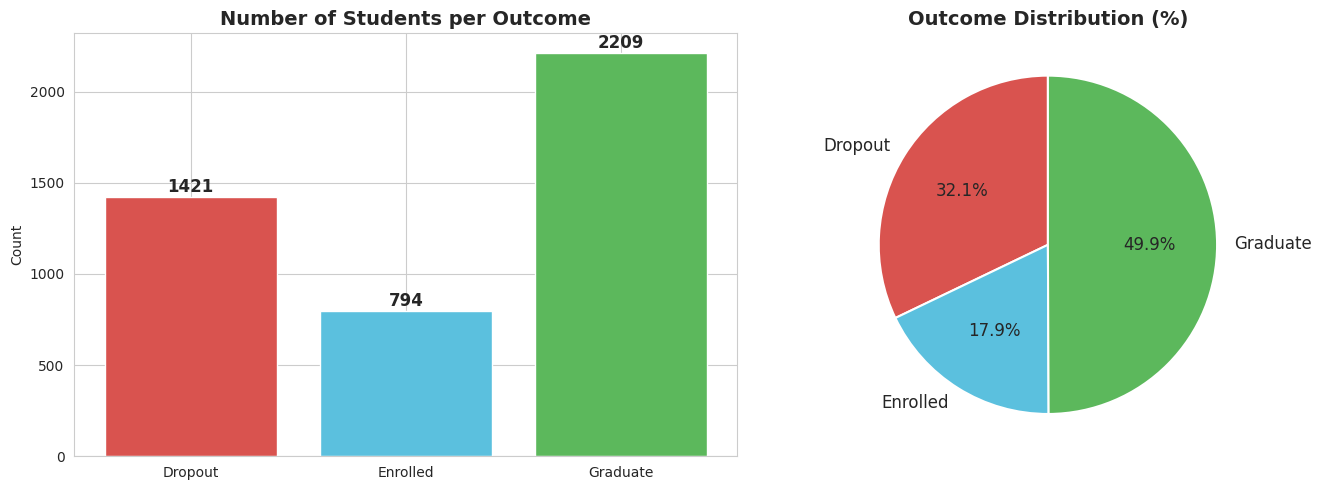


Class breakdown:
  Dropout   : 1421 students (32.1%)
  Enrolled  :  794 students (17.9%)
  Graduate  : 2209 students (49.9%)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

target_counts = df['target'].value_counts()
colors = ['#D9534F', '#5BC0DE', '#5CB85C']
target_order = ['Dropout', 'Enrolled', 'Graduate']

axes[0].bar(target_order, [target_counts[t] for t in target_order], color=colors, edgecolor='white', linewidth=1)
for i, t in enumerate(target_order):
    axes[0].text(i, target_counts[t] + 30, str(target_counts[t]), ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Number of Students per Outcome', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')

axes[1].pie([target_counts[t] for t in target_order], labels=target_order, colors=colors,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12},
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Outcome Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'target_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'\nClass breakdown:')
for t in target_order:
    pct = target_counts[t] / len(df) * 100
    print(f'  {t:10s}: {target_counts[t]:4d} students ({pct:.1f}%)')

The classes are uneven. Graduates make up nearly half the dataset, while Enrolled accounts for only 18%. That means accuracy alone will not be a good evaluation metric, because a model could predict Graduate every time and still look reasonably strong. We will use balanced accuracy and F1 score instead.

### 6.2 Summary Statistics for Continuous Variables



In [ ]:

print('Summary statistics for continuous variables:\n')
df[continuous_features].describe().round(2)

Summary statistics for continuous variables:



,previous_qualification_grade,admission_grade,age_at_enrollment,unemployment_rate,inflation_rate,gdp
count,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00
mean,132.61,126.98,23.27,11.57,1.23,0.00
std,13.19,14.48,7.59,2.66,1.38,2.27
min,95.00,95.00,17.00,7.60,-0.80,-4.06
25%,125.00,117.90,19.00,9.40,0.30,-1.70
50%,133.10,126.10,20.00,11.10,1.40,0.32
75%,140.00,134.80,25.00,13.90,2.60,1.79
max,190.00,190.00,70.00,16.20,3.70,3.51


Age ranges from 17 to 70, but the average is around 23, so most students are younger and only a few older ones stretch the range upward. Admission grades and previous qualification grades fall roughly between 95 and 190. The macro variables, like unemployment and inflation, are not really about the student themselves; they just show what the economy looked like when that person enrolled.

### 6.3 Distribution of Continuous Features


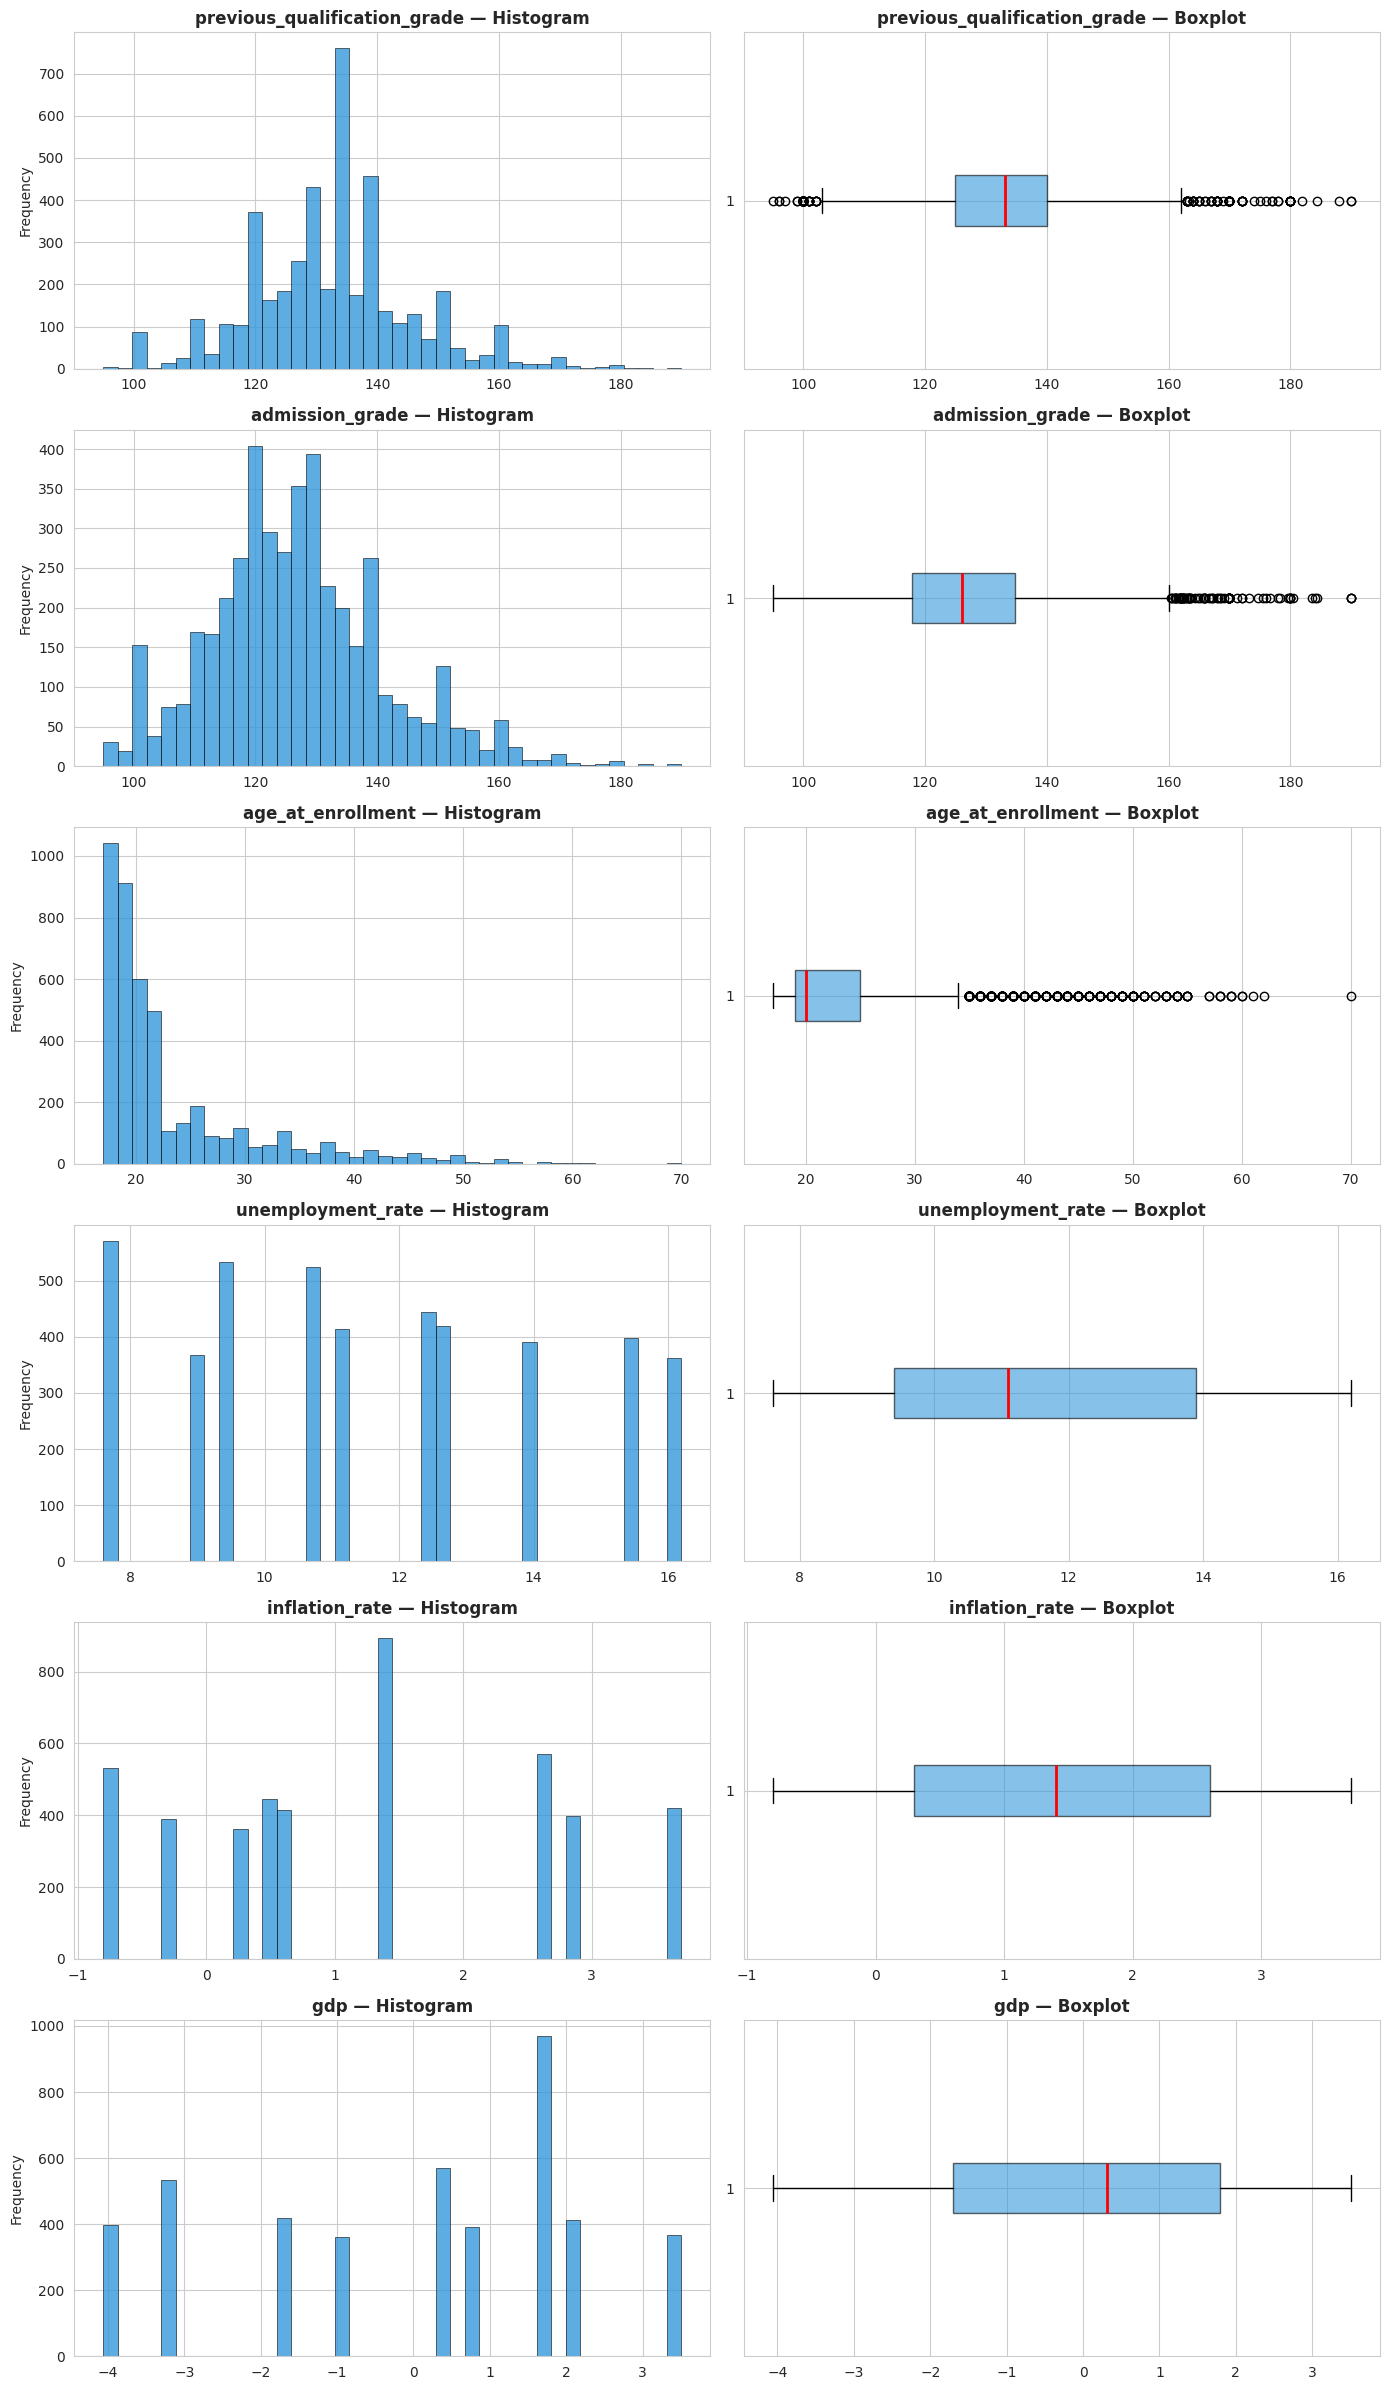

In [ ]:

fig, axes = plt.subplots(len(continuous_features), 2, figsize=(14, 4 * len(continuous_features)))

for i, col in enumerate(continuous_features):
    # Histogram
    axes[i, 0].hist(df[col], bins=40, color='#3498db', edgecolor='black', linewidth=0.5, alpha=0.8)
    axes[i, 0].set_title(f'{col} — Histogram', fontsize=12, fontweight='bold')
    axes[i, 0].set_ylabel('Frequency')

    # Boxplot
    axes[i, 1].boxplot(df[col], vert=False, patch_artist=True,
                       boxprops=dict(facecolor='#3498db', alpha=0.6),
                       medianprops=dict(color='red', linewidth=2))
    axes[i, 1].set_title(f'{col} — Boxplot', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'continuous_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

### 6.4 Outlier Detection (IQR Method)


In [ ]:

print('Outlier detection using IQR method (1.5 * IQR rule):\n')
print(f'{"Feature":45s} {"Q1":>8s} {"Q3":>8s} {"IQR":>8s} {"Lower":>8s} {"Upper":>8s} {"Outliers":>8s}')
print('-' * 95)

outlier_info = {}
for col in continuous_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    outlier_info[col] = {'lower': lower_bound, 'upper': upper_bound, 'count': n_outliers}
    print(f'{col:45s} {Q1:8.2f} {Q3:8.2f} {IQR:8.2f} {lower_bound:8.2f} {upper_bound:8.2f} {n_outliers:8d}')



Outlier detection using IQR method (1.5 * IQR rule):

Feature                                             Q1       Q3      IQR    Lower    Upper Outliers
-----------------------------------------------------------------------------------------------
previous_qualification_grade                    125.00   140.00    15.00   102.50   162.50      179
admission_grade                                 117.90   134.80    16.90    92.55   160.15       86
age_at_enrollment                                19.00    25.00     6.00    10.00    34.00      441
unemployment_rate                                 9.40    13.90     4.50     2.65    20.65        0
inflation_rate                                    0.30     2.60     2.30    -3.15     6.05        0
gdp                                              -1.70     1.79     3.49    -6.94     7.03        0


Age has the most outliers, with 441 in total. These are mature or older students. We will cap them rather than remove them, since older students are a real part of the population.

### 6.5 Binary Feature Analysis



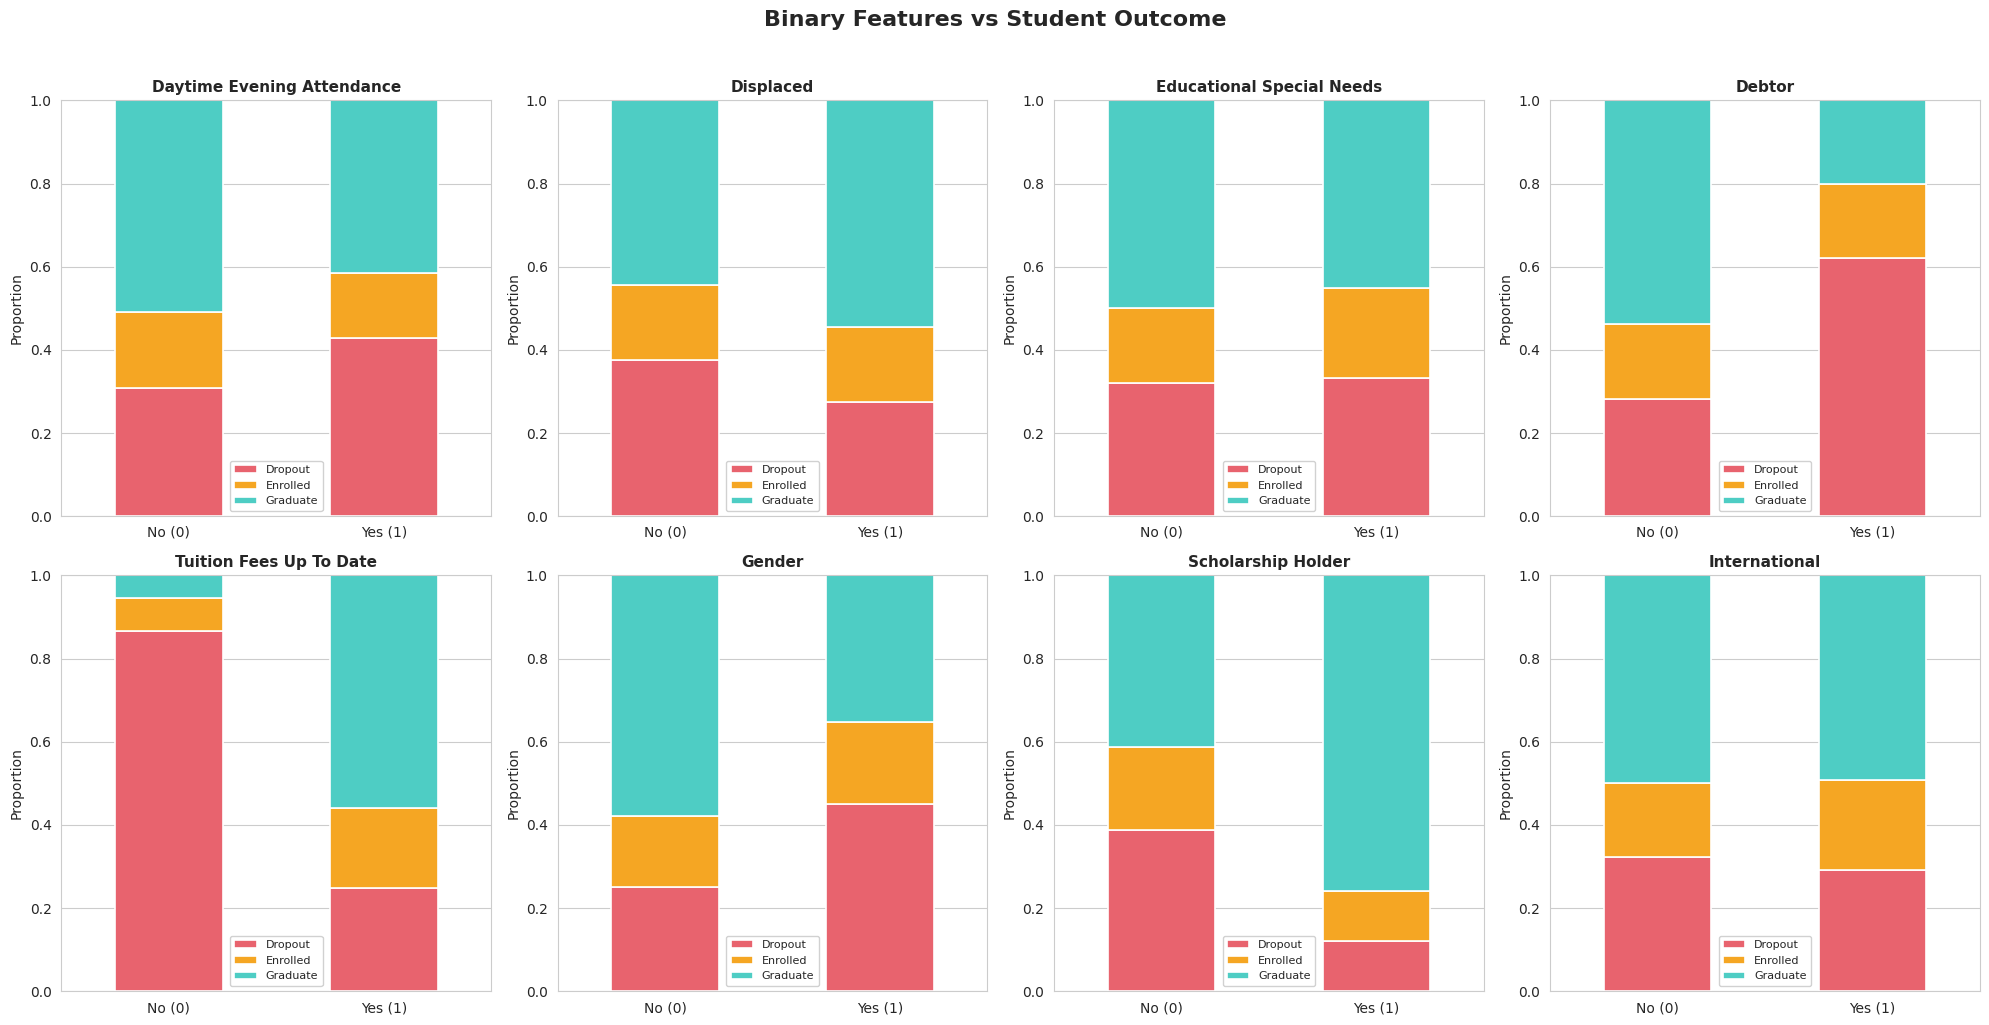

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()


colors = ['#E8636E', '#F5A623', '#4ECDC4']

for i, col in enumerate(binary_features):
    ct = pd.crosstab(df[col], df['target'], normalize='index')
    ct = ct[['Dropout', 'Enrolled', 'Graduate']]

    ct.plot(kind='bar', stacked=True, ax=axes[i], color=colors, edgecolor='white', linewidth=1.2)
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Proportion')
    axes[i].set_xticklabels(['No (0)', 'Yes (1)'], rotation=0)
    axes[i].legend(fontsize=8, framealpha=0.9)
    axes[i].set_ylim(0, 1)

plt.suptitle('Binary Features vs Student Outcome', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'binary_features_vs_target.png'), dpi=150, bbox_inches='tight')
plt.show()

A few patterns stand out quite clearly. Tuition fees are the biggest one. If a student is not up to date on fees, there is an 86.6% chance they will drop out. That is a very large difference. Scholarships matter too, with a 76% graduation rate for students who have one, compared with 41% for those who do not. Debt shows a similar pattern, with a 62% dropout rate for students with debt versus 28% for those without. Male students also seem to drop out more often, at 45% compared with 25% for female students, although that may be linked to other factors we have not untangled yet.

### 6.6 Correlation Heatmap

We compute a correlation matrix for all numeric features, along with the encoded target variable. This helps us see which features have the strongest linear relationship with the outcome and whether any features are strongly correlated with each other, which could create problems for some models.

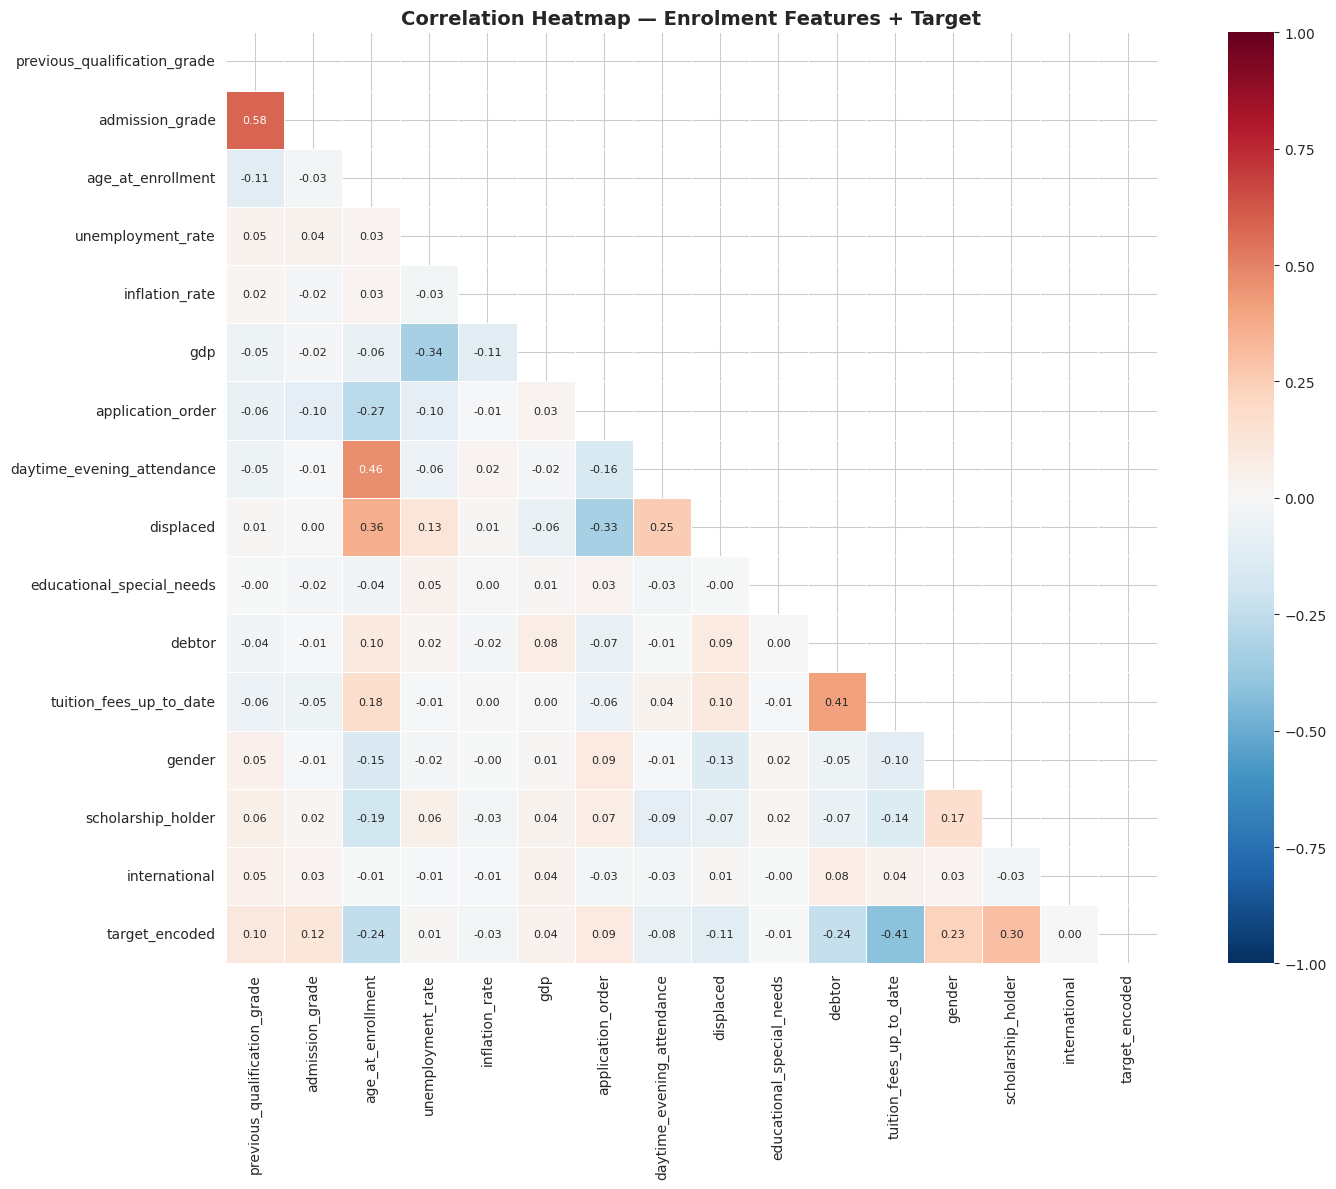


Correlations with Target (Dropout=0, Enrolled=1, Graduate=2):

Most associated with DROPOUT (negative correlation):
  tuition_fees_up_to_date                   -0.4098
  age_at_enrollment                         -0.2434
  debtor                                    -0.2410
  displaced                                 -0.1140
  daytime_evening_attendance                -0.0751

Most associated with GRADUATION (positive correlation):
  application_order                         +0.0898
  previous_qualification_grade              +0.1038
  admission_grade                           +0.1209
  gender                                    +0.2293
  scholarship_holder                        +0.2976


In [ ]:
# Correlation heatmap
df_corr = df.copy()
target_map = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
df_corr['target_encoded'] = df_corr['target'].map(target_map)

for col in binary_features:
    if df_corr[col].dtype == 'object':
        df_corr[col] = pd.factorize(df_corr[col])[0]

numeric_cols = continuous_features + ordinal_features + binary_features + ['target_encoded']
corr_matrix = df_corr[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            annot_kws={'size': 8})
ax.set_title('Correlation Heatmap — Enrolment Features + Target', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'correlation_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

target_corr = corr_matrix['target_encoded'].drop('target_encoded').sort_values()
print('\nCorrelations with Target (Dropout=0, Enrolled=1, Graduate=2):\n')
print('Most associated with DROPOUT (negative correlation):')
for feat, val in target_corr.head(5).items():
    print(f'  {feat:40s}  {val:+.4f}')
print('\nMost associated with GRADUATION (positive correlation):')
for feat, val in target_corr.tail(5).items():
    print(f'  {feat:40s}  {val:+.4f}')

### 6.7 ANOVA Test — Continuous Features
We use one-way ANOVA to check whether the continuous features have different means across the three outcome classes. If a feature has a p-value above 0.05, there is no statistically significant difference between the groups, so it is probably not useful for classification.

In [ ]:

SelectedPredictors=[]
def FunctionAnova(inpData, TargetVariable, ContinuousPredictorList):
    from scipy.stats import f_oneway




    print('##### ANOVA Results ##### \n')
    for predictor in ContinuousPredictorList:
        CategoryGroupLists=inpData.groupby(TargetVariable)[predictor].apply(list)
        AnovaResults = f_oneway(*CategoryGroupLists)


        if (AnovaResults[1] < 0.05):
            print(predictor, 'is correlated with', TargetVariable, '| P-Value:', AnovaResults[1])
            SelectedPredictors.append(predictor)
        else:
            print(predictor, 'is NOT correlated with', TargetVariable, '| P-Value:', AnovaResults[1])

    return(SelectedPredictors)

Running ANOVA test

In [ ]:

FunctionAnova(inpData=df, TargetVariable='target', ContinuousPredictorList=continuous_features)

##### ANOVA Results ##### 

previous_qualification_grade is correlated with target | P-Value: 1.0777825583187265e-12
admission_grade is correlated with target | P-Value: 4.380466113389808e-16
age_at_enrollment is correlated with target | P-Value: 1.138848633132498e-65
unemployment_rate is correlated with target | P-Value: 0.002699757038015915
inflation_rate is NOT correlated with target | P-Value: 0.17529171243976469
gdp is correlated with target | P-Value: 0.008280870491705995


['previous_qualification_grade',
 'admission_grade',
 'age_at_enrollment',
 'unemployment_rate',
 'gdp']

From the ANOVA results, inflation_rate did not show a significant difference across the three groups, so we drop it because it does not add value to the model.

In [ ]:
df = df.drop(columns=['inflation_rate'], errors='ignore')
continuous_features.remove('inflation_rate')

### 6.8 Chi-Square Test — Categorical Features

We use the same idea for categorical and binary features. The chi-square test checks whether the distribution of a categorical variable differs significantly across the target classes. Features with p > 0.05 fail this test and are dropped.

In [ ]:

SelectedPredictors=[]
def FunctionChisq(inpData, TargetVariable, CategoricalVariablesList):
    from scipy.stats import chi2_contingency




    for predictor in CategoricalVariablesList:
        CrossTabResult=pd.crosstab(index=inpData[TargetVariable], columns=inpData[predictor])
        ChiSqResult = chi2_contingency(CrossTabResult)


        if (ChiSqResult[1] < 0.05):
            print(predictor, 'is correlated with', TargetVariable, '| P-Value:', ChiSqResult[1])
            SelectedPredictors.append(predictor)
        else:
            print(predictor, 'is NOT correlated with', TargetVariable, '| P-Value:', ChiSqResult[1])

    return(SelectedPredictors)

Running the chi-square

In [ ]:
CategoricalVariables=binary_features+coded_categorical_features+ordinal_features

FunctionChisq(inpData=df,
              TargetVariable='target',
              CategoricalVariablesList= CategoricalVariables)

daytime_evening_attendance is correlated with target | P-Value: 5.743834299642715e-07
displaced is correlated with target | P-Value: 2.8763109461402734e-13
educational_special_needs is NOT correlated with target | P-Value: 0.7254049737386095
debtor is correlated with target | P-Value: 4.8585521232318114e-57
tuition_fees_up_to_date is correlated with target | P-Value: 1.4716282631420466e-179
gender is correlated with target | P-Value: 2.2224795668092454e-51
scholarship_holder is correlated with target | P-Value: 9.593930375514133e-90
international is NOT correlated with target | P-Value: 0.5273143969362435
marital_status is correlated with target | P-Value: 8.054279703889337e-10
application_mode is correlated with target | P-Value: 1.9646567814647118e-77
course is correlated with target | P-Value: 2.3165709040666167e-97
previous_qualification is correlated with target | P-Value: 7.160305160682533e-30
nationality is NOT correlated with target | P-Value: 0.24222552059446276
mothers_qualif

['daytime_evening_attendance',
 'displaced',
 'debtor',
 'tuition_fees_up_to_date',
 'gender',
 'scholarship_holder',
 'marital_status',
 'application_mode',
 'course',
 'previous_qualification',
 'mothers_qualification',
 'fathers_qualification',
 'mothers_occupation',
 'fathers_occupation',
 'application_order']

In [ ]:
df = df.drop(columns=['educational_special_needs', 'international', 'nationality'], errors='ignore')


binary_features = [f for f in binary_features if f in SelectedPredictors]


coded_categorical_features = [f for f in coded_categorical_features if f in SelectedPredictors]


### 6.9 Multicollinearity Check — Continuous Features

We use Spearman correlation to check whether any of the remaining continuous features are highly correlated with each other. If two features carry almost the same information, we only need one of them.

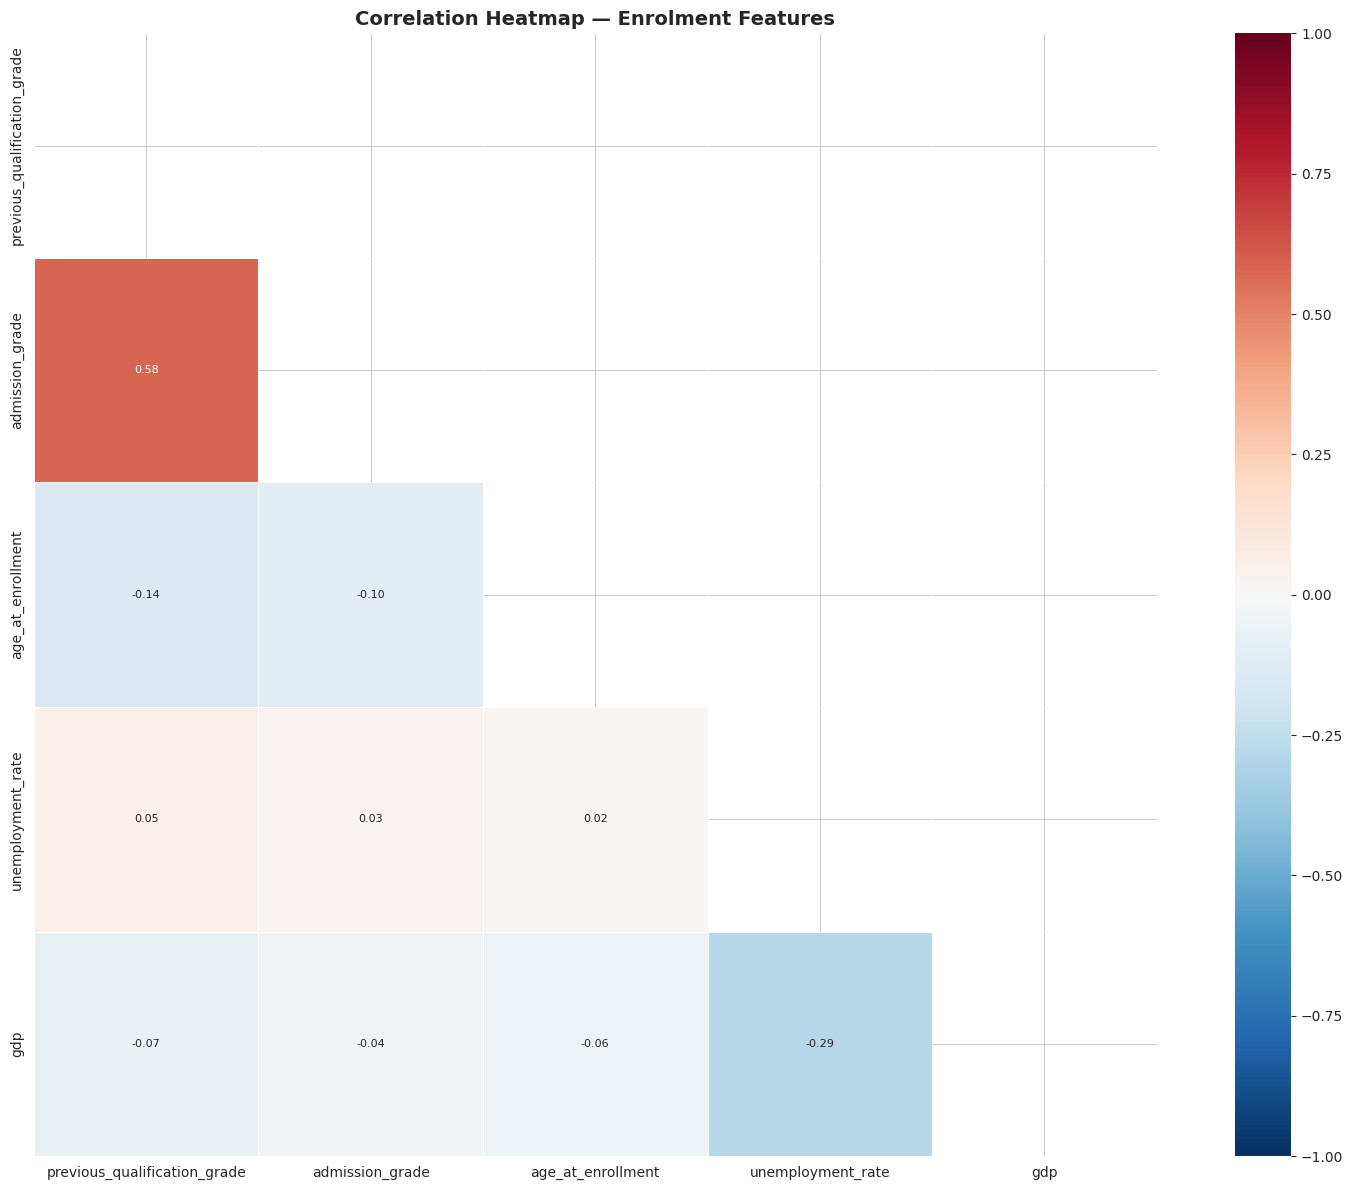

--- HIGHLY REDUNDANT CONTINUOUS FEATURES ---
No continuous features have a correlation above 0.75.


In [ ]:
import pandas as pd
import numpy as np




cont_corr_matrix = df[continuous_features].corr(method='spearman')
fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(cont_corr_matrix, dtype=bool))
sns.heatmap(cont_corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            annot_kws={'size': 8})
ax.set_title('Correlation Heatmap — Enrolment Features', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'correlation_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

print("--- HIGHLY REDUNDANT CONTINUOUS FEATURES ---")

cont_pairs = cont_corr_matrix.unstack().sort_values(key=abs, ascending=False)
cont_pairs = cont_pairs[cont_pairs != 1.0]
cont_pairs = cont_pairs.drop_duplicates()


threshold = 0.75
high_cont_corr = cont_pairs[abs(cont_pairs) > threshold]

if len(high_cont_corr) == 0:
    print(f"No continuous features have a correlation above {threshold}.")
else:
    for pair, val in high_cont_corr.items():
        print(f"{pair[0]} & {pair[1]}: {val:.4f}")

### 6.10 Cramér's V — Categorical Feature Association

Cramér's V measures how strongly two categorical variables are associated, on a scale from 0 to 1. A value close to 0 means little or no association, while a value close to 1 means the two features are almost telling us the same thing. If two categorical features have a very high Cramér's V, we consider dropping one.

In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as ss
import itertools


def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion_matrix, correction=False)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape


    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)


    denominator = min((kcorr-1), (rcorr-1))
    if denominator == 0:
        return 0.0

    return np.sqrt(phi2corr / denominator)


cat_bin_features = coded_categorical_features + binary_features

cramers_results = []


for feat1, feat2 in itertools.combinations(cat_bin_features, 2):
    assoc_value = cramers_v(df[feat1], df[feat2])
    cramers_results.append({
        'Feature 1': feat1,
        'Feature 2': feat2,
        'Cramers_V': assoc_value
    })

df_cramers = pd.DataFrame(cramers_results)
df_cramers = df_cramers.sort_values(by='Cramers_V', ascending=False).reset_index(drop=True)


print("\n--- HIGHLY REDUNDANT CATEGORICAL/BINARY FEATURES ---")
threshold_cat = 0.60
high_cat_assoc = df_cramers[df_cramers['Cramers_V'] > threshold_cat]

if len(high_cat_assoc) == 0:
    print(f"No categorical/binary features have an association above {threshold_cat}.")
else:
    for _, row in high_cat_assoc.iterrows():
        print(f"{row['Feature 1']} & {row['Feature 2']}: {row['Cramers_V']:.4f}")


--- HIGHLY REDUNDANT CATEGORICAL/BINARY FEATURES ---
course & daytime_evening_attendance: 0.9983


Based on the Cramér's V analysis, daytime_evening_attendance was redundant with another feature, so we dropped it to reduce noise.

In [ ]:

df = df.drop(columns=['daytime_evening_attendance'])


binary_features.remove('daytime_evening_attendance')

print("Redundant features successfully dropped!")

Redundant features successfully dropped!


## 7. Data Preprocessing



### 7.1 Outlier Capping

Rather than removing outliers, we cap them at the IQR boundaries. This way extreme values get pulled in to the edge of the normal range but the student records are not lost. For example, a 65-year-old student would get capped to the upper boundary, not deleted from the dataset.

In [ ]:


def cap_outliers_iqr(dataframe, columns, factor=1.5):
    """Cap outliers at 1.5*IQR boundaries. Returns the modified dataframe."""
    df_capped = dataframe.copy()
    for col in columns:
        Q1 = df_capped[col].quantile(0.25)
        Q3 = df_capped[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - factor * IQR
        upper = Q3 + factor * IQR
        before = ((df_capped[col] < lower) | (df_capped[col] > upper)).sum()
        df_capped[col] = df_capped[col].clip(lower=lower, upper=upper)
        print(f'  {col}: capped {before} outliers to [{lower:.2f}, {upper:.2f}]')
    return df_capped

print('Capping outliers in continuous features:\n')
df = cap_outliers_iqr(df, continuous_features)
print('\nDone. Outliers have been capped, not removed.')

Capping outliers in continuous features:

  previous_qualification_grade: capped 179 outliers to [102.50, 162.50]
  admission_grade: capped 86 outliers to [92.55, 160.15]
  age_at_enrollment: capped 441 outliers to [10.00, 34.00]
  unemployment_rate: capped 0 outliers to [2.65, 20.65]
  gdp: capped 0 outliers to [-6.94, 7.03]

Done. Outliers have been capped, not removed.


### 7.2 Handle Rare Categories

A few of the categorical columns have categories with barely any students in them — like single digit counts. If we one-hot encode those as is we end up with columns that are almost entirely zeros which doesn't really help the model, just adds noise. So anything with fewer than 20 students gets lumped into an "Other" group before we do the encoding.

In [ ]:
#A few of the categorical columns have categories with very few students in them.
# If we one-hot encode them as they are, we end up with columns that are almost all zeros, which just adds noise.
#To avoid that, we group anything with fewer than 20 students into a single "Other" category before encoding.
RARE_THRESHOLD = 20

def group_rare_categories(dataframe, columns, threshold):
    """Replace rare category values with -1 (representing 'Other')."""
    df_grouped = dataframe.copy()
    for col in columns:
        value_counts = df_grouped[col].value_counts()
        rare_values = value_counts[value_counts < threshold].index.tolist()
        if len(rare_values) > 0:
            n_affected = df_grouped[col].isin(rare_values).sum()
            df_grouped[col] = df_grouped[col].replace(rare_values, -1)
            new_unique = df_grouped[col].nunique()
            print(f'  {col}: grouped {len(rare_values)} rare categories '
                  f'({n_affected} rows) into "Other" -> {new_unique} categories now')
    return df_grouped

print(f'Grouping categories with fewer than {RARE_THRESHOLD} students:\n')
df = group_rare_categories(df, coded_categorical_features, RARE_THRESHOLD)
print('\nThis reduces the number of columns we will get after one-hot encoding.')

Grouping categories with fewer than 20 students:

  marital_status: grouped 2 rare categories (10 rows) into "Other" -> 5 categories now
  application_mode: grouped 6 rare categories (32 rows) into "Other" -> 13 categories now
  course: grouped 1 rare categories (12 rows) into "Other" -> 17 categories now
  previous_qualification: grouped 9 rare categories (56 rows) into "Other" -> 9 categories now
  mothers_qualification: grouped 19 rare categories (68 rows) into "Other" -> 11 categories now
  fathers_qualification: grouped 24 rare categories (82 rows) into "Other" -> 11 categories now
  mothers_occupation: grouped 20 rare categories (90 rows) into "Other" -> 13 categories now
  fathers_occupation: grouped 34 rare categories (112 rows) into "Other" -> 13 categories now

This reduces the number of columns we will get after one-hot encoding.


### 7.3 Encode the Target Variable



In [ ]:
target_mapping = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
df['target'] = df['target'].map(target_mapping)

print('Target encoding:')
for label, code in target_mapping.items():
    count = (df['target'] == code).sum()
    print(f'  {label:10s} -> {code}  ({count} students)')

print(f'\nTarget dtype: {df["target"].dtype}')

Target encoding:
  Dropout    -> 0  (1421 students)
  Enrolled   -> 1  (794 students)
  Graduate   -> 2  (2209 students)

Target dtype: int64


### 7.4 One-Hot Encoding for Categorical Features


In [ ]:
for col in coded_categorical_features:
    df[col] = df[col].astype(str)

import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Define the transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False), coded_categorical_features),
        ('bin', OneHotEncoder(drop='if_binary', sparse_output=False), binary_features),
        ('pass', 'passthrough', continuous_features + ordinal_features)
    ],
    verbose_feature_names_out=False
)

X_encoded_array = preprocessor.fit_transform(df)
feature_names = preprocessor.get_feature_names_out()
X = pd.DataFrame(X_encoded_array, columns=feature_names)

print(X.head())

   marital_status_divorced  marital_status_facto union  \
0                      0.0                         0.0   
1                      0.0                         0.0   
2                      0.0                         0.0   
3                      0.0                         0.0   
4                      0.0                         0.0   

   marital_status_married  marital_status_single  \
0                     0.0                    1.0   
1                     0.0                    1.0   
2                     0.0                    1.0   
3                     0.0                    1.0   
4                     1.0                    0.0   

   application_mode_1st phase-general contingent  \
0                                            0.0   
1                                            0.0   
2                                            1.0   
3                                            0.0   
4                                            0.0   

   application_mode_1st p

Checking the shape after encoding to see how many features we ended up with.

In [ ]:
X.shape

(4424, 95)

### 7.5 Feature Selection — Random Forest Importance

Using a Random Forest to rank features by how much they contribute to classification. This helps us narrow down the feature set and drop columns that aren't adding much.

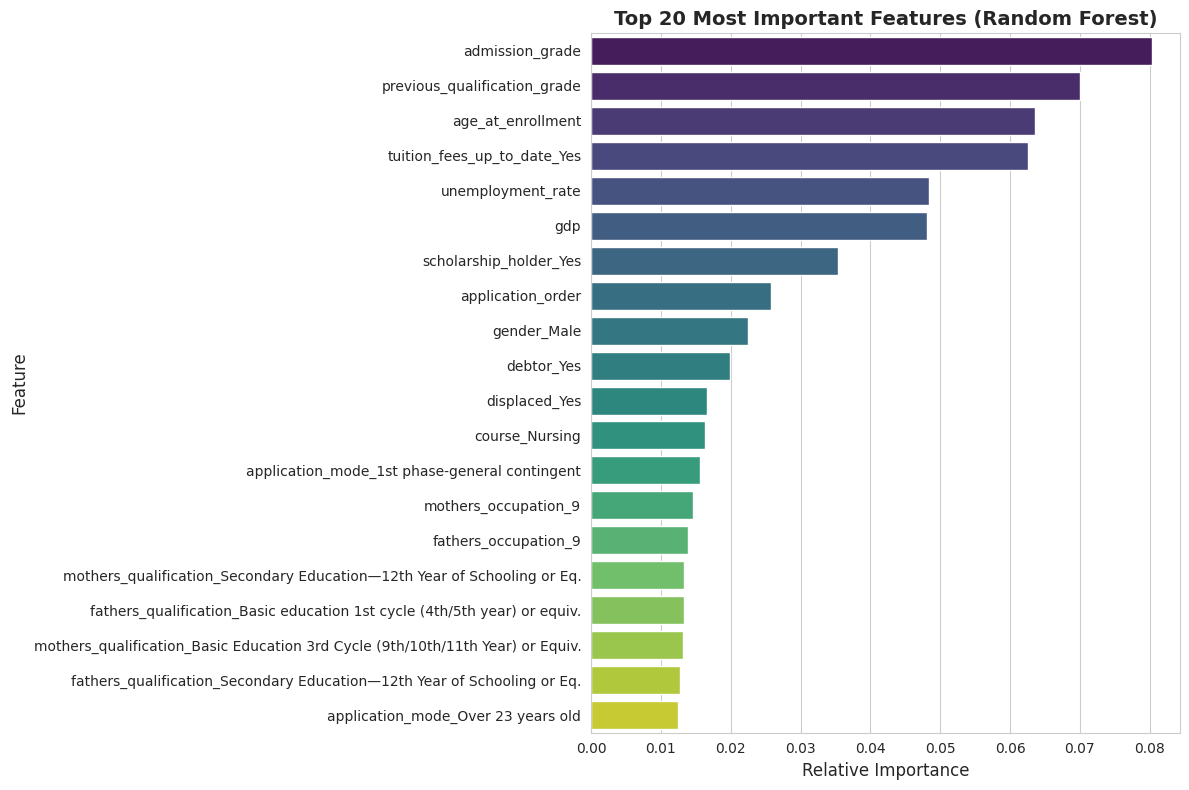


--- TOP 20 FEATURES BY IMPORTANCE ---
 1. admission_grade                               (0.0803)
 2. previous_qualification_grade                  (0.0700)
 3. age_at_enrollment                             (0.0636)
 4. tuition_fees_up_to_date_Yes                   (0.0626)
 5. unemployment_rate                             (0.0484)
 6. gdp                                           (0.0480)
 7. scholarship_holder_Yes                        (0.0353)
 8. application_order                             (0.0258)
 9. gender_Male                                   (0.0224)
10. debtor_Yes                                    (0.0199)
11. displaced_Yes                                 (0.0165)
12. course_Nursing                                (0.0163)
13. application_mode_1st phase-general contingent (0.0156)
14. mothers_occupation_9                          (0.0147)
15. fathers_occupation_9                          (0.0138)
16. mothers_qualification_Secondary Education—12th Year of Schooling or Eq. 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier


y = df['target']
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X, y)

importances = rf_model.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

plt.figure(figsize=(12, 8))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df.head(20),
    palette='viridis'
)

plt.title('Top 20 Most Important Features (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Relative Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'rf_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()


print("\n--- TOP 20 FEATURES BY IMPORTANCE ---")
for i, row in feature_importance_df.head(20).iterrows():
    print(f"{i+1:2d}. {row['Feature']:45s} ({row['Importance']:.4f})")


feature_importance_df['Cumulative_Importance'] = feature_importance_df['Importance'].cumsum()
num_features_95 = len(feature_importance_df[feature_importance_df['Cumulative_Importance'] <= 0.95]) + 1
print(f"\nNote: You only need the top {num_features_95} features to retain 95% of the total predictive power.")

Selecting the top 68 features based on importance scores. This cuts out the weakest features that were mostly noise after one-hot encoding.

In [ ]:

top_68_features = feature_importance_df['Feature'].head(68).tolist()


X_final = X[top_68_features]

print(f"Original shape: {X.shape}")
print(f"New shape: {X_final.shape}")

Original shape: (4424, 95)
New shape: (4424, 68)


### 7.6 Train/Test Split

Splitting 80/20 with stratification to keep the same class proportions in both sets. Data is saved unscaled — each team member handles scaling in their own individual notebook depending on whether their model needs it (SVM and kNN do, Decision Tree and Naive Bayes don't).

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape[0]} samples, {X_train.shape[1]} features')
print(f'Test set:     {X_test.shape[0]} samples, {X_test.shape[1]} features')

print(f'\nClass distribution (training):')
for code_val, label in {0: 'Dropout', 1: 'Enrolled', 2: 'Graduate'}.items():
    pct = (y_train == code_val).sum() / len(y_train) * 100
    print(f'  {label:10s}: {(y_train == code_val).sum():4d} ({pct:.1f}%)')

Training set: 3539 samples, 68 features
Test set:     885 samples, 68 features

Class distribution (training):
  Dropout   : 1137 (32.1%)
  Enrolled  :  635 (17.9%)
  Graduate  : 1767 (49.9%)


## 8. Final Feature Summary

A quick summary of what the preprocessed dataset looks like before we save it and move on to modelling.

In [ ]:
print('Final preprocessed dataset summary')
print('=' * 50)
print(f'Training samples:  {X_train.shape[0]}')
print(f'Test samples:      {X_test.shape[0]}')
print(f'Total features:    {X_train.shape[1]}')
print(f'Target classes:    3 (Dropout=0, Enrolled=1, Graduate=2)')

Final preprocessed dataset summary
Training samples:  3539
Test samples:      885
Total features:    68
Target classes:    3 (Dropout=0, Enrolled=1, Graduate=2)


## 9. PCA Visualisation

After one-hot encoding we ended up with quite a lot of features. PCA lets us project the data down to just 2 dimensions so we can visualise it on a scatter plot and see whether the three classes separate at all. This is not meant to be a perfect picture since we are throwing away most of the information, but it gives a rough idea of how hard the classification problem is.

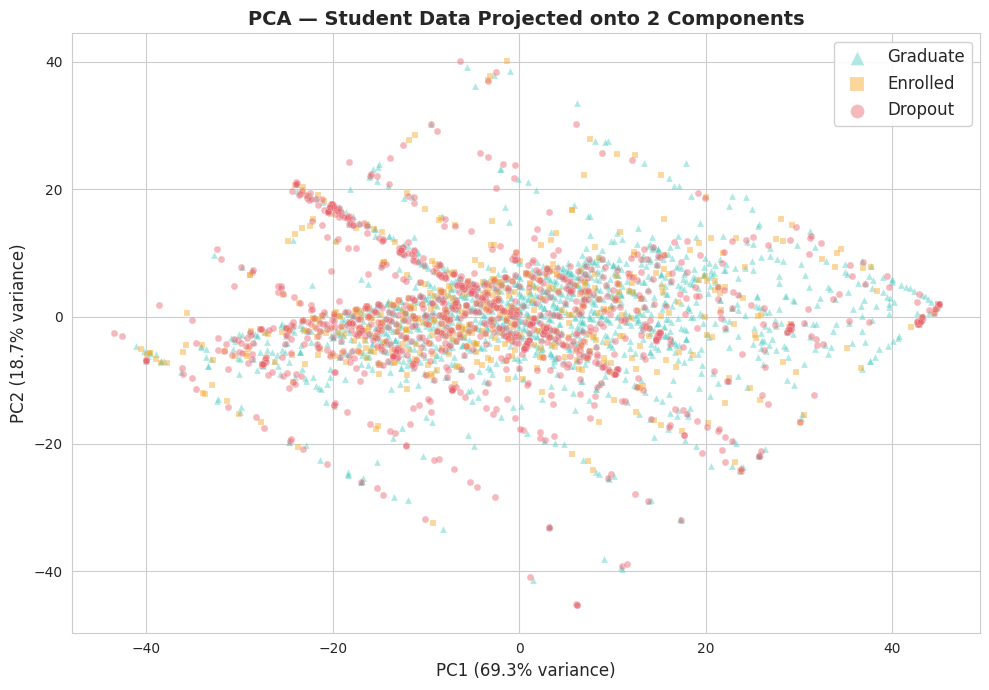

Total variance explained by 2 components: 88.0%


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train)

fig, ax = plt.subplots(figsize=(10, 7))

scatter_config = {
    0: {'color': '#E8636E', 'label': 'Dropout',  'marker': 'o'},
    1: {'color': '#F5A623', 'label': 'Enrolled', 'marker': 's'},
    2: {'color': '#4ECDC4', 'label': 'Graduate', 'marker': '^'},
}

for code in [2, 1, 0]:
    mask = y_train == code
    cfg = scatter_config[code]
    ax.scatter(X_train_pca[mask, 0], X_train_pca[mask, 1],
              c=cfg['color'], marker=cfg['marker'], label=cfg['label'],
              alpha=0.45, s=25, edgecolors='white', linewidth=0.3)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
ax.set_title('PCA — Student Data Projected onto 2 Components', fontsize=14, fontweight='bold')
ax.legend(fontsize=12, markerscale=2, framealpha=0.9)

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'pca_visualisation.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'Total variance explained by 2 components: {pca.explained_variance_ratio_.sum()*100:.1f}%')

## 10. Save Preprocessed Data

We save the training and test sets as CSV files so each team member can load them directly into their individual modelling notebooks without repeating any of the preprocessing.

In [ ]:
train_data = pd.DataFrame(X_train, columns=X_final.columns)
train_data['target'] = y_train.values

test_data = pd.DataFrame(X_test, columns=X_final.columns)
test_data['target'] = y_test.values

train_path = os.path.join(PREPROCESSED_DIR, 'train_preprocessed.csv')
test_path = os.path.join(PREPROCESSED_DIR, 'test_preprocessed.csv')

train_data.to_csv(train_path, index=False)
test_data.to_csv(test_path, index=False)

print(f'Saved: {train_path}')
print(f'  ({train_data.shape[0]} rows, {train_data.shape[1]} columns)')
print(f'\nSaved: {test_path}')
print(f'  ({test_data.shape[0]} rows, {test_data.shape[1]} columns)')
print(f'\nData is saved UNSCALED. Each team member handles scaling in their own notebook if needed.')

Saved: /content/drive/MyDrive/COMM074_Project/preprocessed/train_preprocessed.csv
  (3539 rows, 69 columns)

Saved: /content/drive/MyDrive/COMM074_Project/preprocessed/test_preprocessed.csv
  (885 rows, 69 columns)

Data is saved UNSCALED. Each team member handles scaling in their own notebook if needed.


---

## Summary of What We Found

So the dataset is definitely imbalanced — graduates make up roughly half, dropouts about a third, and enrolled students are the smallest group at 18%. That's going to matter when we train and evaluate, we'll either need class weights or oversampling to stop the models just favouring the majority class.

Biggest takeaway from the EDA is tuition fees. If a student is behind on payments the dropout rate is 86.6% which is a massive red flag on its own. Scholarships and debt status also came through strongly. On the demographics side older students and males tend to drop out more.

Admission grade has a decent correlation with graduating which kind of makes sense — students who got in with higher grades tend to do better. The macro stuff (unemployment, inflation, GDP) didn't really show obvious differences between the groups but we're keeping them in anyway since they might add something when combined with other features.
One thing to keep in mind going into modelling is that after encoding we've got around 101 features which is quite a lot. That could be an issue for distance-based models like kNN and SVM so we'll see how that plays out.

